# pySCENIC Network — Exploratory Analysis

**Files**: `scenic_net_CD4_act`, `scenic_net_CD4_rest`, `scenic_net_CD8_act`, `scenic_net_CD8_rest`, `scenic_net_full`, `pyscenic_net_edges`

**Goal**: Understand what's in each network before cross-network benchmarking.

Sections:
1. Load all files + inspect columns
2. Basic stats per network (edges, TFs, targets)
3. TF coverage
4. Top TFs by edge count and weight
5. Activation vs resting TF comparison (CD4 and CD8)
6. Overlap between state networks
7. Visualizations

In [18]:
# ── 0. Setup ─────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

STATES = ['CD4_rest', 'CD4_act', 'CD8_rest', 'CD8_act']

# Map each state to its correct deltaRSS column
DELTA_COL = {
    'CD4_rest': 'delRSS_CD4',
    'CD4_act':  'delRSS_CD4',
    'CD8_rest': 'delRSS_CD8',
    'CD8_act':  'delRSS_CD8',
}

# Color palette per state
STATE_COLORS = {
    'CD4_rest': '#4C9BE8',
    'CD4_act':  '#1A5FAD',
    'CD8_rest': '#E8834C',
    'CD8_act':  '#AD3D1A',
}

In [19]:
# ── 1. Build long-form DataFrame for grouped plots ───────────────────────────
records = []
for state in STATES:
    df   = nets[state].copy()
    col  = DELTA_COL[state]
    vals = df[col].dropna()
    lineage, condition = state.split('_')   # 'CD4'/'CD8', 'rest'/'act'
    for v in vals:
        records.append({
            'state':     state,
            'lineage':   lineage,
            'condition': condition,
            'deltaRSS':  v,
        })

long_df = pd.DataFrame(records)
print(long_df.groupby('state')['deltaRSS'].describe().round(4))

            count    mean     std     min     25%     50%     75%     max
state                                                                    
CD4_act   16133.0  0.0327  0.0190  0.0004  0.0176  0.0375  0.0451  0.1094
CD4_rest  10886.0 -0.0246  0.0234 -0.2041 -0.0298 -0.0185 -0.0085 -0.0001
CD8_act    8417.0  0.0074  0.0048  0.0014  0.0045  0.0075  0.0104  0.0387
CD8_rest  18602.0 -0.0192  0.0119 -0.0802 -0.0265 -0.0179 -0.0114 -0.0002


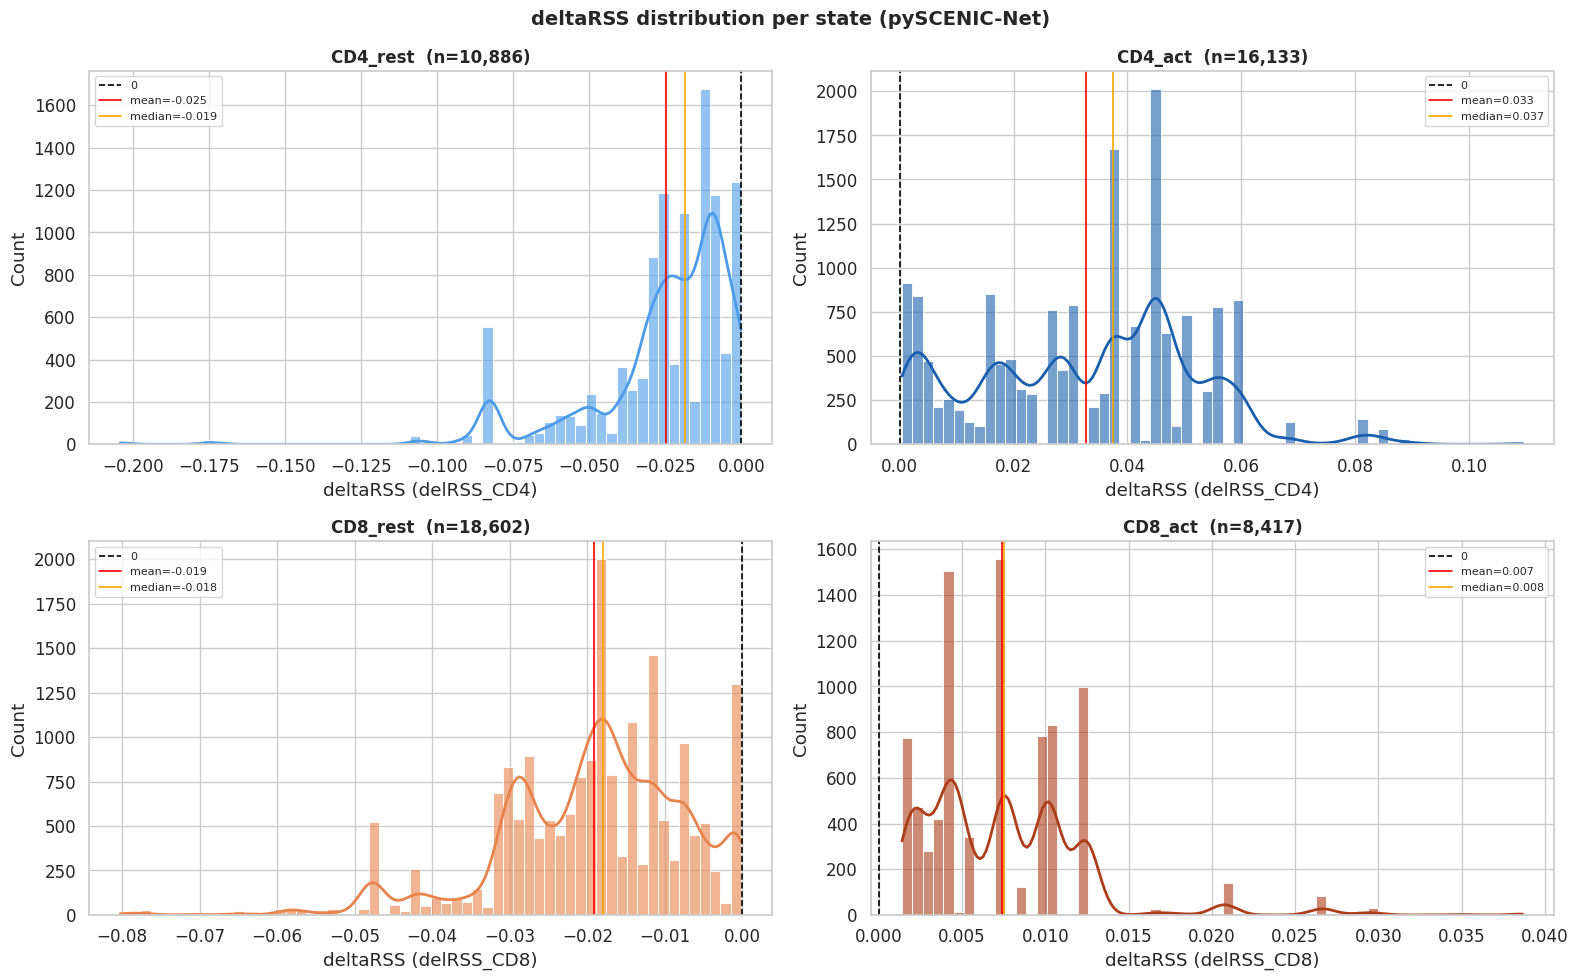

In [20]:
# ── 2. Distribution per state — histogram + KDE overlay ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, state in enumerate(STATES):
    ax  = axes[i]
    col = DELTA_COL[state]
    vals = nets[state][col].dropna()

    sns.histplot(vals, bins=60, kde=True, ax=ax,
                 color=STATE_COLORS[state], alpha=0.6,
                 line_kws={'lw': 2})

    ax.axvline(0,            color='black',  lw=1.2, ls='--', label='0')
    ax.axvline(vals.mean(),  color='red',    lw=1.2, ls='-',  label=f'mean={vals.mean():.3f}')
    ax.axvline(vals.median(),color='orange', lw=1.2, ls='-',  label=f'median={vals.median():.3f}')

    ax.set_title(f'{state}  (n={len(vals):,})', fontweight='bold', fontsize=12)
    ax.set_xlabel(f'deltaRSS ({DELTA_COL[state]})')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('deltaRSS distribution per state (pySCENIC-Net)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/delRSS_per_state.png', dpi=150, bbox_inches='tight')
plt.show()